Introductory Remark: I had some issues with the installation of the TabPFN library on my engine, since I wanted to run the library locally. To run the installation locally it is necessary to:

1. have the following local installations:

$$\texttt{pip install catboost xgboost}$$
$$\texttt{pip install datasets}$$
$$\texttt{pip install rich}$$
$$\texttt{pip install 'tabpfn-extensions[all]'}$$
$$\texttt{pip install tabpfn}$$


Since the initial installs were failing I consulted with the Github documentation. The following two cells were taken from the Github demonstration and conveniently allow to choose between client and local versions of the run and are marked with a link.

In [53]:
"""
This cell was copied from their demo Github https://github.com/PriorLabs/TabPFN/blob/main/examples/notebooks/TabPFN_Demo_Local.ipynb
"""
# Standard Library Imports

# TabPFN

try:
    from tabpfn import TabPFNClassifier, TabPFNRegressor
except ImportError:
    raise ImportError(
        "Warning: Could not import TabPFN. Please run installation above and restart the session afterwards (Runtime > Restart Session)."
    )

# Data Science & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


# Notebook UI/Display
from IPython.display import Markdown, display
from rich.console import Console
from rich.panel import Panel
from rich.rule import Rule
from sklearn.compose import make_column_selector, make_column_transformer

# Scikit-Learn: Data & Preprocessing
from sklearn.datasets import fetch_openml, load_breast_cancer

# Scikit-Learn: Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# This transformer will be used to handle categorical features for the baseline models
column_transformer = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        make_column_selector(dtype_include=["object", "category"]),
    ),
    remainder="passthrough",
)



In [54]:
"""
This cell was copied from their demo Github https://github.com/PriorLabs/TabPFN/blob/main/examples/notebooks/TabPFN_Demo_Local.ipynb
"""
# Authentication code - No need to read it!

console = Console()

console.print(Panel.fit("[bold magenta]TabPFN Demo: Backend Selection[/bold magenta]"))
console.print("\nThis script can run TabPFN using one of two backends:")
console.print("  [bold]local:[/bold] Uses a local GPU (NVIDIA). Requires CUDA.")
console.print(
    "  [bold]client:[/bold] Uses the TabPFN API. Requires an internet connection and a free account."
)

backend = None
while backend is None:
  console.print(
      "\n[bold]Choose your backend[/bold]: - If no text box is shown, restart the cell.",
  )
  user_input = input("Enter 'local' or 'client' and press return:")
  if user_input not in ["local", "client"]:
    continue
  backend = user_input

console.print(
    f"\n✅ You have selected the '[bold green]{backend}[/bold green]' backend."
)

console.print(Rule(f"[bold]Setting up [cyan]{backend}[/cyan] backend[/bold]"))

if backend == "local":
    console.print("Attempting local backend setup...")
    import torch

    if not torch.cuda.is_available():
        console.print(
            "[bold red]Error:[/bold red] GPU device not found. For fast training, please enable GPU.",
            style="red",
        )
        console.print(
            "In Colab: Go to [bold]Runtime -> Change runtime type -> Hardware accelerator -> GPU.[/bold]",
            style="yellow",
        )
        raise SystemError("GPU device not found.")
    console.print("[bold green]✅ GPU is available.[/bold green]")

    # --- Prior Labs Authentication ---
    console.print(Rule("[bold]Prior Labs Authentication[/bold]"))
    console.print(
        "\nTabPFN model weights require a free [bold]Prior Labs account[/bold] and "
        "acceptance of the non-commercial license.\n"
    )

    import os
    import getpass

    tabpfn_token = None

    # 1. Try Colab secret TABPFN_TOKEN
    try:
        from google.colab import userdata
        tabpfn_token = userdata.get("TABPFN_TOKEN")
        if tabpfn_token:
            os.environ["TABPFN_TOKEN"] = tabpfn_token
            console.print("[bold green]✅ Found TABPFN_TOKEN in Colab secrets.[/bold green]")
    except Exception:
        pass

    # 2. If no token found, prompt the user
    if not tabpfn_token:
        console.print(
            Panel(
                "To get your access token:\n\n"
                "  1. Go to [link=https://ux.priorlabs.ai]ux.priorlabs.ai[/link] and sign up / log in\n"
                "  2. Accept the license at [link=https://ux.priorlabs.ai/account/licenses]ux.priorlabs.ai/account/licenses[/link]\n"
                "  3. Copy your Access Token from [link=https://ux.priorlabs.ai/account]ux.priorlabs.ai/account[/link]\n\n"
                "[bold yellow]Tip:[/bold yellow] Save the token as a Colab secret named "
                "[bold cyan]TABPFN_TOKEN[/bold cyan] to skip this step next time.",
                title="[bold]🔑 Prior Labs Access Token required",
                border_style="blue",
            )
        )
        while not tabpfn_token:
            token_input = getpass.getpass("Paste your TABPFN_TOKEN and press Enter: ")
            if token_input.strip():
                tabpfn_token = token_input.strip()
                os.environ["TABPFN_TOKEN"] = tabpfn_token
            else:
                console.print("[red]Token cannot be empty. Please try again.[/red]")

    console.print("")
    console.print("Importing local TabPFN library...")

    from tabpfn import TabPFNClassifier, TabPFNRegressor

    console.print("[bold green]✅ TabPFN (local) imported successfully.[/bold green]")
elif backend == "client":
    console.print("Attempting client backend setup...")
    console.print("Importing TabPFN client library...")
    from tabpfn_client import TabPFNClassifier, TabPFNRegressor, init

    init()
    console.print("[bold green]✅ TabPFN (client) initialized.[/bold green]")

╭────────────────────────────────╮
│ TabPFN Demo: Backend Selection │
╰────────────────────────────────╯

This script can run TabPFN using one of two backends:

local: Uses a local GPU (NVIDIA). Requires CUDA.

client: Uses the TabPFN API. Requires an internet connection and a free account.

Choose your backend: - If no text box is shown, restart the cell.

...

──────────────────────────────────────────── Prior Labs Authentication ────────────────────────────────────────────

TabPFN model weights require a free Prior Labs account and acceptance of the non-commercial license.

╭────────────────────────────────────── 🔑 Prior Labs Access Token required ──────────────────────────────────────╮
│ To get your access token:                                                                                       │
│                                                                                                                 │
│   1. Go to ]8;id=1505461;https://ux.priorlabs.ai\ux.priorlabs.ai]8;;\ and sign up / log in                                                                 │
│   2. Accept the license at ]8;id=1505462;https://ux.priorlabs.ai/account/licenses\ux.priorlabs.ai/account/licenses]8;;\                                                     │
│   3. Copy your Access Token from ]8;id=1505463;https://ux.priorlabs.ai/account\ux.priorlabs.ai/account]8;;\                                                        │
│                                                                                                                 │
│ Tip: Save the token as a Colab secret named TABPFN_TOKEN to skip this step next time.                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Importing local TabPFN library...

✅ TabPFN (local) imported successfully.

569


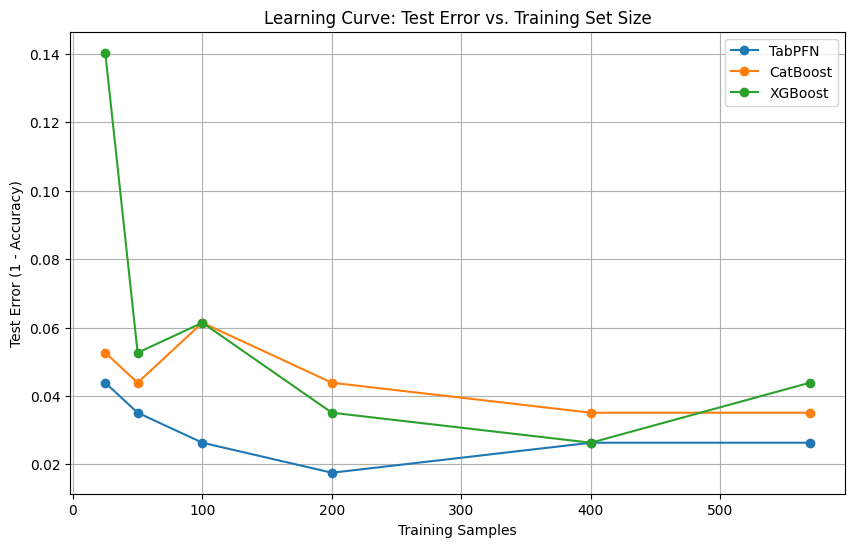

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tabpfn import TabPFNClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# 1. Setup Data
X, y = load_breast_cancer(return_X_y=True)
#print(len(X))
# set the testset to 20% of the data thats totally available
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sizes = [25, 50, 100, 200, 400, 569]
results = {"TabPFN": [], "CatBoost": [], "XGBoost": []} #-> we will compare TabPFN, CatBoost and XGBoost.

# 2. Benchmark Loop 
for size in sizes:
    X_sub, y_sub = X_train_full[:size], y_train_full[:size]
    

    # run the different methods and save their test error in the prepared results
    # TabPFN (Zero-shot)
    tab = TabPFNClassifier(device='cuda') # Use 'cpu' if no GPU
    tab.fit(X_sub, y_sub)
    results["TabPFN"].append(1 - accuracy_score(y_test, tab.predict(X_test)))
    
    # CatBoost (Default)
    cb = CatBoostClassifier(silent=True, iterations=100)
    cb.fit(X_sub, y_sub)
    results["CatBoost"].append(1 - accuracy_score(y_test, cb.predict(X_test)))
    
    # XGBoost (Default)
    xgb = XGBClassifier(n_estimators=100)
    xgb.fit(X_sub, y_sub)
    results["XGBoost"].append(1 - accuracy_score(y_test, xgb.predict(X_test)))

# 3. Plotting for visual comparison
plt.figure(figsize=(10, 6))
for label, errors in results.items():
    plt.plot(sizes, errors, marker='o', label=label)

plt.title("Learning Curve: Test Error vs. Training Set Size")
plt.xlabel("Training Samples")
plt.ylabel("Test Error (1 - Accuracy)")
plt.legend()
plt.grid(True)


# Save as png
plt.savefig('learning_curve_benchmark.png', dpi=300, bbox_inches='tight')

plt.show()

The plot demonstrates twofold:
1. TabPFN consistently outperforms CatBoost and XGBoost, particularly for small training sets.
2. Early stopping and curation of training data greatly improves test error in all compared methods with the test error being minimal for ~ n = 200